In [1]:
import time
import h5py

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import scipy.stats as st

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
from scipy.ndimage._filters import uniform_filter1d as uf
%matplotlib widget 

## Load and plot the data first to see how the data looks

In in the yaml file you need to change the 'TT_corr: {bool: True, offset: 1100}' bool to False if you haven't created the file with TT correction yet

[165. 209. 202. 283. 347. 386. 384. 374. 376. 373. 379. 369. 367. 380.
 379. 375. 387. 371. 375. 386. 361. 370. 379. 375. 373. 357. 370. 372.
 362. 366. 371. 355. 358. 377. 356. 361. 368. 360. 360.]
  despeckle [axis_svls_off_mean]: kernel=3, n_sigma=10 -> flagged 21 pixels (0.068%)
  despeckle [axis_svls_on_mean]: kernel=3, n_sigma=10 -> flagged 34 pixels (0.110%)
  despeckle TOTAL: 55 pixels across 2 map(s)
saving data in ./avg/Run0112to0112.h5
dict_keys(['axis_svls_off_mean', 'axis_svls_off_std', 'axis_svls_off_sum', 'axis_svls_off_sumI0', 'axis_svls_off_sumSV', 'axis_svls_on_mean', 'axis_svls_on_std', 'axis_svls_on_sum', 'axis_svls_on_sumI0', 'axis_svls_on_sumSV', 'counts_off', 'counts_on', 'scanvar_off', 'scanvar_on', 'axis_svls_on_norm', 'axis_svls_off_norm', 'PFY_on_sos', 'PFY_off_sos', 'PFY_on_mean', 'PFY_on_std', 'PFY_off_mean', 'PFY_off_std', 'E_emi'])


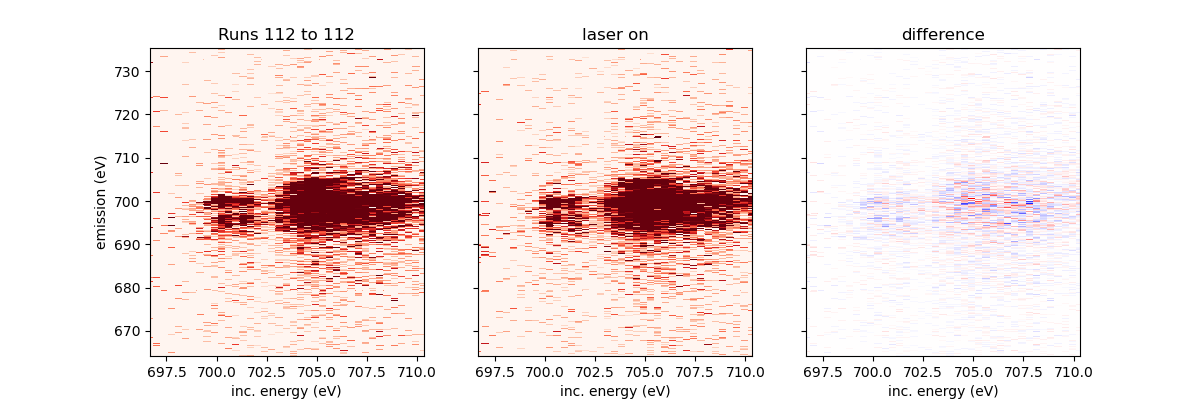

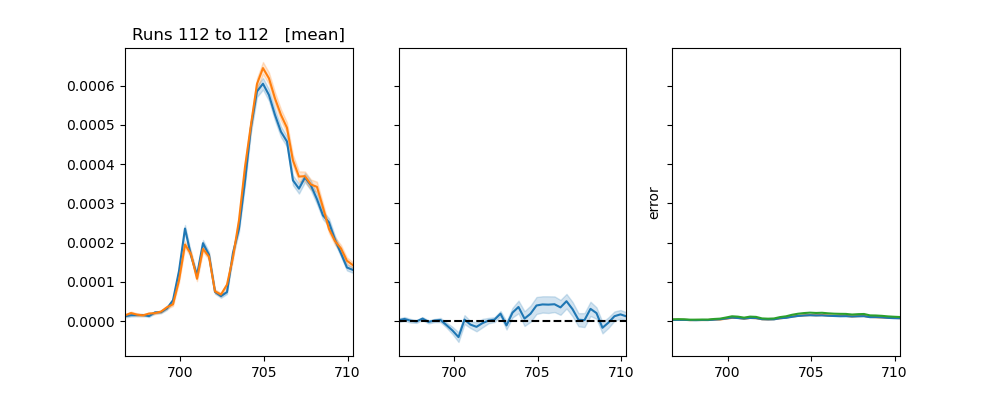

In [5]:
#############single shot data - run 69,112


base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'

bgrun = 86
# bgrun = 143
# runs=[70,71,72,74,75,76,77,78,79,80,81,82,83] # O K-edge A peak time trace
# runs=[84,86,87,88,89,90,91,92,93,94,95,96,97,98,99,102,103,104] # O K-edge B peak time trace
# runs=[112]#[166,167,168,169,170,171,172,173,174,175,176,177,178,180,181,182,183,184,187,188,189,190,191,192,193,195,196,197,198,199,200] # N K-edge B peak time trace

# runs = [200]

runs = [61,62,63,64,65,66,67,68,69]
# runs = [157]
exp = 'rix101231825'
# runs = [114]
# runs = [61,62,63,64,66]
# runs = [68]
# runs = [66]
# runs = [162,163,164,165,166,167,168,169]
runs = [112]

# fyaml = '../roi_inputTT.yml'
fyaml = '../roi_input.yml'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= False,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=False,scale=10)

avg.plot_svls1D(figsize=(10,4),savefig=False)

avg.save_avg()
# 

In [32]:
E = avg.average['E_emi']
emi_lo, emi_hi = sorted([np.argmin(np.abs(E-698)), np.argmin(np.abs(E-702))])

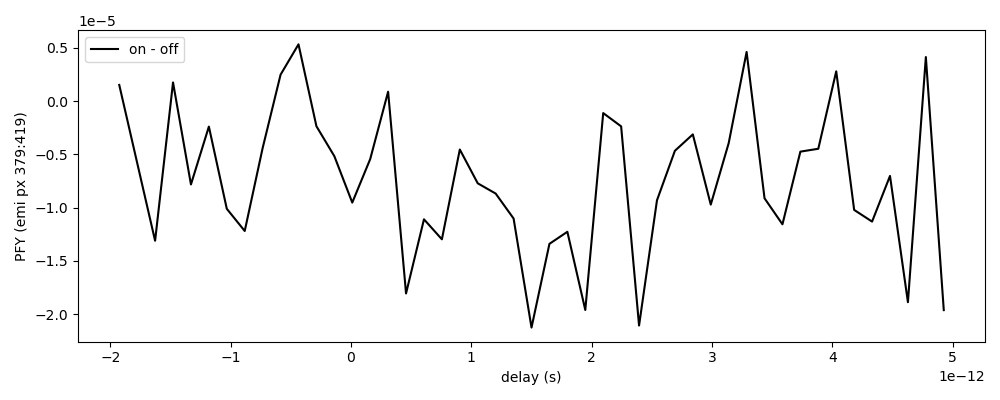

In [33]:
# emi_lo, emi_hi = 698, 702        # emission pixel range to sum (check avg.average['axis_svls_on_mean'].shape[1])

on   = avg.average['axis_svls_on_mean']
off  = avg.average['axis_svls_off_mean']
x_on  = avg.average['scanvar_on']
x_off = avg.average['scanvar_off']

pfy_on  = np.nansum(on[:,  emi_lo:emi_hi], axis=1)
pfy_off = np.nansum(off[:, emi_lo:emi_hi], axis=1)

plt.figure(figsize=(10,4))
# plt.plot(x_off, pfy_off, label='off')
# plt.plot(x_on,  pfy_on,  label='on')
plt.plot(x_on,  pfy_on - pfy_off, 'k', label='on - off')
plt.xlabel('delay (s)')
plt.ylabel(f'PFY (emi px {emi_lo}:{emi_hi})')
plt.legend(); plt.tight_layout(); plt.show()

In [6]:
run = runs[0]

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_inputTT.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
# bg = SmallData(bgname, bgyaml)

## Loading the data to look at the piranha (TT) signal

In [8]:
proc = Reduced(fname,bgname,fyaml,bgyaml)

expected_count = st.mode(proc.data.integrating.axis_svls.count, keepdims=False)[0]
mask1 = (proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/proc.data.integrating.axis_svls.count) >0.5

mask2= (proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/expected_count)>0.5
# np.sum(mask1==mask2)
# proc.data.scantype

112
setting up properties
dataset prop <functools.cached_property object at 0x7f62146c13d0>
dataset prop <functools.cached_property object at 0x7f620b0d68d0>
dataset prop <functools.cached_property object at 0x7f6208efaf50>
dataset prop <functools.cached_property object at 0x7f62132e1b50>
dataset prop <functools.cached_property object at 0x7f620af557d0>
dataset prop <functools.cached_property object at 0x7f6208fcbe50>
dataset prop <functools.cached_property object at 0x7f6208f86210>
dataset prop <functools.cached_property object at 0x7f62131c7890>
86
setting up properties
dataset prop <functools.cached_property object at 0x7f6208de2950>
dataset prop <functools.cached_property object at 0x7f6208e70d90>
dataset prop <functools.cached_property object at 0x7f62132383d0>
dataset prop <functools.cached_property object at 0x7f6208de4090>
dataset prop <functools.cached_property object at 0x7f62131d3250>
dataset prop <functools.cached_property object at 0x7f6208f55410>
scanvariable is unkown, b

### Plotting how the nominal delays during the experiment

Just a sanity check

AttributeError: 'AxisSVLS' object has no attribute 'delay'

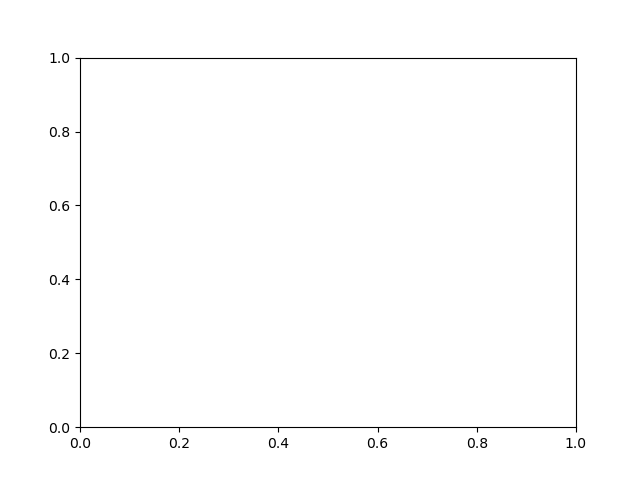

In [9]:
fig,ax=plt.subplots(1,1)
ax.scatter(np.arange(len(proc.data.integrating.axis_svls.delay[mask1])), proc.data.integrating.axis_svls.delay[mask1])
ax.set_ylabel('nominal delay time (fs)')
ax.set_xlabel('frame #')

## Load Piranha

- Loading the piranha data and creating masks for the on and off signal

- Plotting the averaged piranha signals

112
setting up properties
dataset prop <functools.cached_property object at 0x7f620af54810>
dataset prop <functools.cached_property object at 0x7f6209a65490>
dataset prop <functools.cached_property object at 0x7f6208e49790>
dataset prop <functools.cached_property object at 0x7f6208eb1bd0>
dataset prop <functools.cached_property object at 0x7f6208e12410>
dataset prop <functools.cached_property object at 0x7f6208eb1750>
dataset prop <functools.cached_property object at 0x7f6208fc8790>
dataset prop <functools.cached_property object at 0x7f6208e02410>


(0.0, 2000.0)

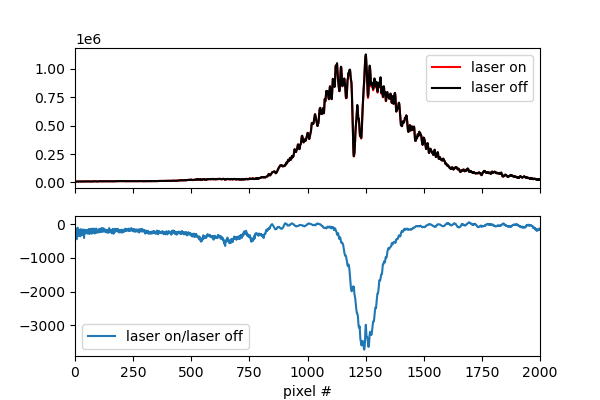

In [9]:

expected_count = st.mode(proc.data.integrating.axis_svls.count, keepdims=False)[0]

data.integrating.axis_svls.piranha.shape
mask_on = ((proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/proc.data.integrating.axis_svls.count) >0.5).squeeze()# (data.integrating.axis_svls.eventcodes[:,272]==1)# np.asarray([data.integrating.axis_svls.eventcodes[:,data.yaml['evc'][True]]/expected_count>0.5]).squeeze()
mask_off = ((proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][False]]/proc.data.integrating.axis_svls.count) >0.5).squeeze() #(data.integrating.axis_svls.eventcodes[:,273]==1)#

piranha = (proc.data.integrating.axis_svls.piranha)
piranha_on = (proc.data.integrating.axis_svls.piranha[mask_on,:])
piranha_off =(proc.data.integrating.axis_svls.piranha[mask_off,:])

fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.nanmean(piranha_on,axis=0).T, 'r',label='laser on')
ax[0].plot(np.nanmean(piranha_off,axis=0).T, 'k',label='laser off')
ax[0].legend()
# ax[1].plot((np.nanmean(piranha_on,axis=0))-(np.mean(piranha_off,axis=0)),label='laser on-laser off')
ax[1].plot(((np.nanmean(piranha_on,axis=0))/(np.mean(piranha_off,axis=0))-1)*2e5,label='laser on/laser off')
ax[1].legend()
ax[1].set_xlabel('pixel #')
ax[1].set_xlim(0,2000)

In [11]:
len(mask_on)

28909

- plot individual piranha traces: it becomes visible how much the signal intensity fluctuates, we will deal with some background subtraction below to deal with this

Text(0.5, 0, 'pixel #')

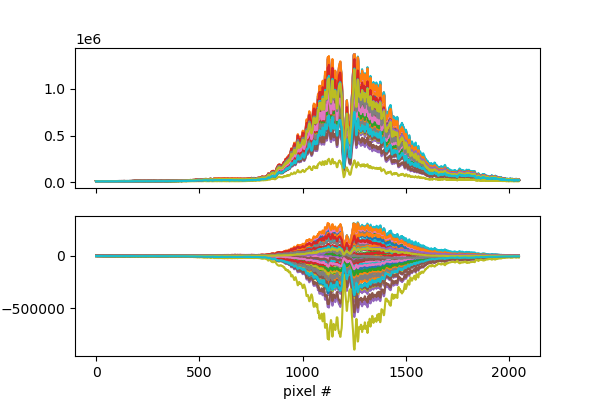

In [7]:
fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot((piranha_on).T[:,:100],label='laser on')
# ax[0].plot(np.nanmean(piranha_off,axis=0).T, 'k',label='laser off')
ax[1].plot(((piranha_on.T[:,:100]))-(np.mean(piranha_off,axis=0))[:,np.newaxis],label='laser on-laser off')
ax[1].set_xlabel('pixel #')


### Do SVD

- Use the plot above of the averaged data of laser on/laser off to determine the ROI (range where the peak is located), the analysis is very sensitive to the ROI, so you may need to play around with it

-  we do the decomposition with a subset of the dark data (N is number of traces), using a larger N will slow down the code quite significantly and I have not seen a visible improvement for the data 

- the last line then does the background subtraction based on the background decomposition, you can choose the number of components (neigs) to use. the analysis below is based on 'traces'

In [10]:
import h5py, scipy.stats as st

with h5py.File(fname, 'r') as fh:
    raw_cnt = np.array(fh['intg/axis_svls/count']).astype(float)
    raw_ts  = np.array(fh['intg/timestamp'])

exp   = st.mode(raw_cnt, keepdims=False)[0]
cmask = (raw_cnt < exp+2) & (raw_cnt > exp-2)     # same ±2 as your integrating.py
ts    = raw_ts[cmask]                              # timestamp for the countmask-kept frames
assert ts.shape[0] == piranha.shape[0]             # alignment sanity check

idx      = np.argsort(ts)
piranha  = piranha[idx]
mask_on  = mask_on[idx]
mask_off = mask_off[idx]
piranha_on, piranha_off = piranha[mask_on], piranha[mask_off]

In [ ]:
max_p = -1
ROI=[1100,1400]
N = 2000
N = piranha_off.shape[0] 
v, s = decomp_((piranha_off[:,:])[:,:],N) #decomposition of BG data (dark)
traces = decomp_1d(v,s,piranha[:,:],ROI,neigs=3) #all data only ROI

Now we are plotting the cleaned up piranha traces, you should see a strong negative signal



When we start seeing detector damages, instead of a somewhat Gaussian shape, you will see areas where it looks like something got simply got cut out of the Gaussian

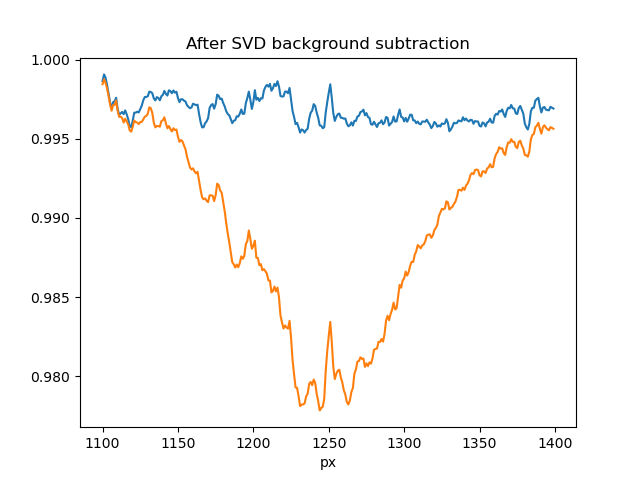

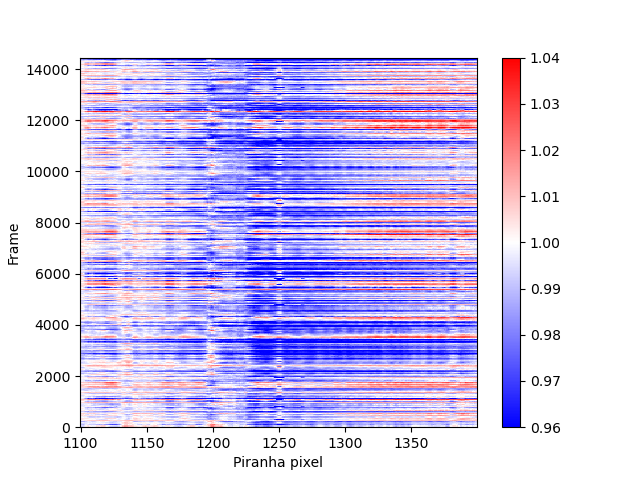

In [12]:

# traces_norm = traces/np.nansum(traces,axis = 1)[:,np.newaxis]

px = np.arange(ROI[0],ROI[1])
plt.figure()
plt.plot(px,np.nanmean(traces[mask_off[:],:],axis =0),label = 'Background')
plt.plot(px,np.nanmean(traces[mask_on[:],:],axis =0),label = 'Signal')
plt.title('After SVD background subtraction')
plt.xlabel('px')
plt.show()
plt.figure()
shots = np.arange(len(traces[mask_on[:]]))
plt.pcolormesh(px,np.arange(traces[mask_on[:]].shape[0]),traces[mask_on[:]],cmap = 'bwr',vmin = 0.96,vmax = 1.04)
# plt.pcolormesh(traces_norm[mask_on],cmap = 'bwr',vmin = 0.0023,vmax = 0.004)
plt.xlabel('Piranha pixel')
plt.ylabel('Frame')
plt.colorbar()
plt.show()



Text(0.5, 0, 'on-shot fraction per frame')

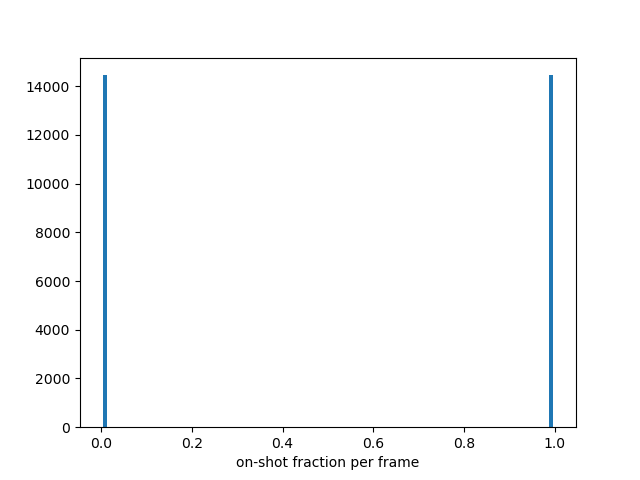

In [42]:
frac = (proc.data.integrating.axis_svls.eventcodes[:, proc.data.yaml['evc'][True]]
        / proc.data.integrating.axis_svls.count)
plt.figure()
plt.hist(frac, bins=100); plt.xlabel('on-shot fraction per frame')

This was just a test to see if it would be easier to look at the differential for finding the edge, the fitting analysis below seems to be more robust

In [10]:


# ds=uf(np.diff(uf(traces[mask_on[:]],size=1,axis=1,mode='nearest'),axis=1),size=10,axis=1,mode='nearest')
# ds.shape

# px = np.arange(ROI[0],ROI[1])
# plt.figure()
# # plt.plot(px,np.nanmean(traces[mask_off[:2000],:],axis =0),label = 'Background')
# plt.plot(ds[100:200,:].T,label = 'Signal')
# plt.title('After SVD background subtraction')
# plt.xlabel('px')
# plt.show()
# plt.figure()
# shots = np.arange(len(ds))
# plt.pcolormesh(ds,cmap = 'bwr',vmin=-0.01,vmax=0.01)
# plt.xlabel('Piranha pixel')
# plt.ylabel('Shot')
# plt.colorbar()
# plt.show()

In [14]:
def find_edge(y):
    x = np.arange(len(y))
    slopes = np.diff(y)/np.diff(x)
    try:
        p,cov = fit_LS(asymmetric_gaussian,x,y,[1.,x[y==y.max()][0],20,60,7e-5,1e-3])
    except:
        print('FIT FAILED :(') 
        return -9999.0,-9999.0,-9999.0, slopes
    yfit = asymmetric_gaussian(x,*p[:,0])
    slopesfit = np.diff(yfit)/np.diff(x)
    idx = np.where(slopes==slopes.max())[0][0]
    idxfit = np.where(slopesfit==slopesfit.max())[0][0]
    amp = slopesfit[idxfit]
    fwhm = find_fwhm(slopesfit)
    return idxfit,amp,fwhm, slopesfit

In [15]:
def fit_gaussian_fast_linear(x, y, lb, ub):
    tmp = gaussian_moments_linear(x, y)
    p0 = [tmp[0],tmp[1],tmp[2]/2,tmp[2],tmp[3],tmp[4]]
    bounds = [lb, ub]

    if np.any(np.isnan(p0[:3])):
        return p0

    try:
        p0 = np.asarray(p0)
        p0[p0 < lb] = lb[p0 < lb]
        p0[p0 > ub] = ub[p0 > ub]

        popt, _ = curve_fit(
            # gaussian_linear,
            asymmetric_gaussian, #(x, A, mu, sigma1, sigma2,C,D)
            x,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=3000
        )
        return popt
    except RuntimeError:
        return p0

def asymmetric_gaussian(x, A, mu, sigma1, sigma2,C,D):
    return np.where(x < mu,
                    A * np.exp(-((x - mu)**2) / (2 * sigma1**2)),
                    A * np.exp(-((x - mu)**2) / (2 * sigma2**2)))+D*x+C

## Fit Gaussian

Now the magic happens: I use the functions defined above to fit a Gaussian to the individual traces

- IMPORTANT: updated the input upper and lower bounds (ub and lb) according to how the traces look for your run

- when fitting: we first determine the Gaussian moment and then use that as input parameters for the fit. If the Gaussian moment parameters are outside the boundaries, they are set to the closer upper or lower bound

- We fit an asymmetric Gaussian, the 'lower side' sigma is then subtracted from the x0 to determine the edge position

In [48]:

px = np.arange(ROI[0],ROI[1])
x = px
spectra = -traces[mask_on[:]]
# spectra = np.zeros([10,traces.shape[1]])
# for i in np.arange(10):
#     spectra[i,:] = np.mean(2-traces[mask_on[:2000]][i*100:(i+1)*100,:],axis=0)

spectra.shape == (traces[mask_on[:]].shape[0], traces[mask_on[:]].shape[1])
x.shape == (traces[mask_on[:]].shape[0],)
params = np.array([
    gaussian_moments_linear(x, spectra[i])
    for i in range(spectra.shape[0])
])
lb = np.array([0., 1000,  1, 1,   -1.2, -1])  # A, mu, sigma, C (lower)
ub = np.array([1, 1350, 150, 200, -0.8, 1])    
params_fit = np.array([
    fit_gaussian_fast_linear(x, spectra[i],lb,ub)
    for i in range(spectra.shape[0])
])



A     = params[:, 0]
mu    = params[:, 1]
sigma = params[:, 2]
sigma1 = params[:, 2]
A_fit     = params_fit[:, 0]
mu_fit    = params_fit[:, 1]
sigma_fit = params_fit[:, 2]
sigma_fit1 = params_fit[:, 3]


'''
This is an alternative way to determine the edge from the max of the differential - does not make a difference, so I go with a simple mu-sigma, easier calculation
leading_edge_max  = np.array([
                                x[np.argmax(np.diff(asymmetric_gaussian(x, params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4]))/np.diff(x))]
                                for i in np.arange(params.shape[0])
                                ])#mu - sigma
leading_edge_fit_max  = np.array([
                                x[np.argmax(np.diff(asymmetric_gaussian(x, *params_fit[i,:]))/np.diff(x))] 
                                for i in np.arange(params_fit.shape[0])
                                ])#mu - sigma

'''
leading_edge  = mu - sigma
leading_edge_fit  = mu_fit - sigma_fit


14454 on-shots | seed-fallback (no real fit): 0 (0.0%) | median resid RMS 0.0040
param         %@lb   %@ub    median
A               0.0    0.0   0.018
μ (center)      0.0    0.0   1246.380
σ₁ (lead)       1.1    2.7   44.733
σ₂ (trail)      0.0    0.6   48.281
C (offset)      0.0    0.0   -1.006
D (slope)       0.0    0.0   0.000


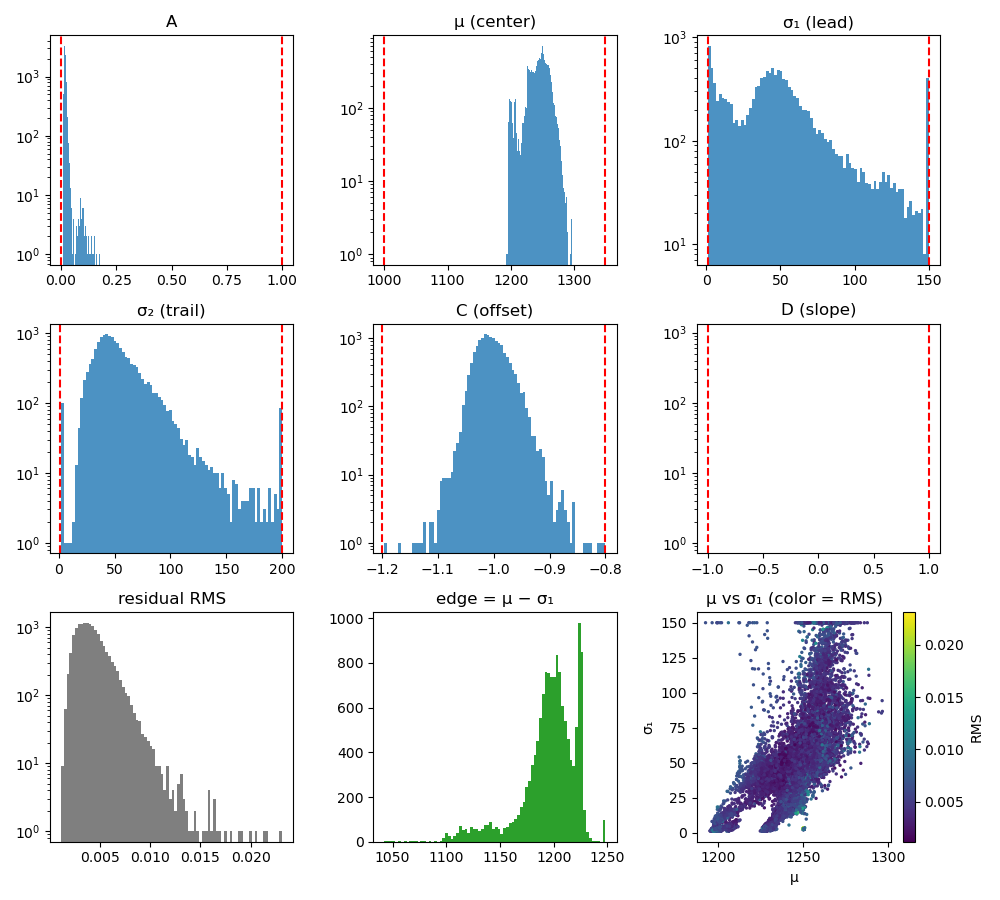

In [49]:
names = ['A', 'μ (center)', 'σ₁ (lead)', 'σ₂ (trail)', 'C (offset)', 'D (slope)']
P = params_fit                                   # (N_on, 6)
N = len(P)

# fit quality: per-shot residual RMS of the fitted model vs the data it was fit to
model = np.array([asymmetric_gaussian(x, *P[i]) for i in range(N)])
rms   = np.sqrt(np.nanmean((spectra - model)**2, axis=1))

# flag fits that just returned the moment seed (curve_fit failed / NaN seed)
seed = np.column_stack([params[:,0], params[:,1], params[:,2]/2,
                        params[:,2], params[:,3], params[:,4]])
fell_back = (np.all(np.isclose(P, np.clip(seed, lb, ub)), axis=1)
             | ~np.isfinite(P[:, :3]).all(axis=1))

tol = 1e-3 * (ub - lb)                            # "sitting on the bound" tolerance
print(f'{N} on-shots | seed-fallback (no real fit): {fell_back.sum()} '
      f'({100*fell_back.mean():.1f}%) | median resid RMS {np.nanmedian(rms):.4f}')
print('param         %@lb   %@ub    median')
for j, nm in enumerate(names):
    at_lb = 100*np.mean(np.isclose(P[:,j], lb[j], atol=tol[j]))
    at_ub = 100*np.mean(np.isclose(P[:,j], ub[j], atol=tol[j]))
    print(f'{nm:12s} {at_lb:6.1f} {at_ub:6.1f}   {np.nanmedian(P[:,j]):.3f}')

fig, ax = plt.subplots(3, 3, figsize=(10, 9)); ax = ax.ravel()
for j, nm in enumerate(names):
    ax[j].hist(P[:,j], bins=80, color='tab:blue', alpha=0.8); ax[j].set_yscale('log')
    ax[j].axvline(lb[j], c='r', ls='--'); ax[j].axvline(ub[j], c='r', ls='--')
    ax[j].set_title(nm)
ax[6].hist(rms, bins=80, color='tab:gray');            ax[6].set_yscale('log'); ax[6].set_title('residual RMS')
ax[7].hist(P[:,1]-P[:,2], bins=80, color='tab:green'); ax[7].set_title('edge = μ − σ₁')
sc = ax[8].scatter(P[:,1], P[:,2], c=rms, s=2, cmap='viridis')
ax[8].set_xlabel('μ'); ax[8].set_ylabel('σ₁'); ax[8].set_title('μ vs σ₁ (color = RMS)')
plt.colorbar(sc, ax=ax[8], label='RMS'); plt.tight_layout(); plt.show()

Plot a 2D maps of the input traces and compare them to the ones reconstructed fit (middle), and from Gaussian moment (right).

If the fit does not look like the data at all, go back to the previous cell and update the lower and upper bounds

Text(0, 0.5, 'frame (#)')

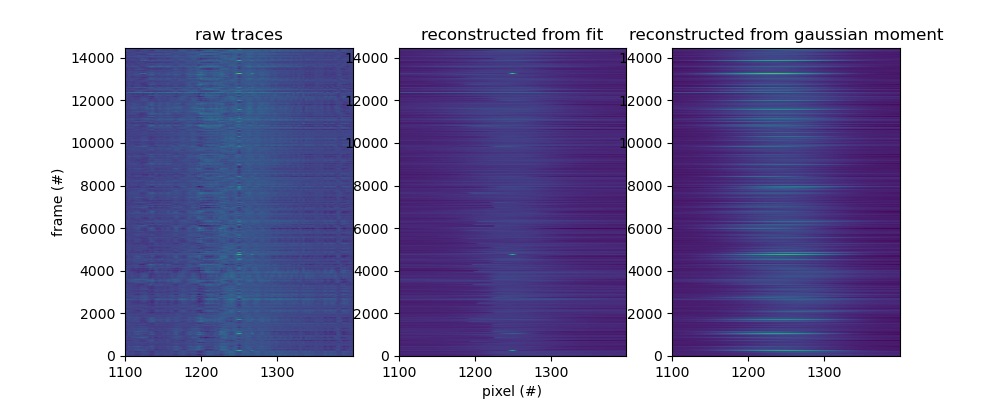

In [50]:
fit = np.array([
    asymmetric_gaussian(x, *params_fit[i,:])
    for i in range(spectra.shape[0])
])

fit_moment = np.array([
    asymmetric_gaussian(x, params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4])
    for i in range(spectra.shape[0])
])

fig,ax=plt.subplots(1,3,figsize=(10,4))
ax[0].pcolor(px, np.arange(spectra.shape[0]),spectra)
ax[0].set_title('raw traces')
ax[1].pcolor(px, np.arange(spectra.shape[0]),fit)
ax[1].set_title('reconstructed from fit')
ax[2].pcolor(px, np.arange(spectra.shape[0]),fit_moment)
ax[2].set_title('reconstructed from gaussian moment')

ax[1].set_xlabel('pixel (#)')
ax[0].set_ylabel('frame (#)')

Let's look at the distribution of edge positions - there's a lot of commented out lines, uncomment them if you want to compare the edge positions from different way of determining them, the label should tell you what they stand for

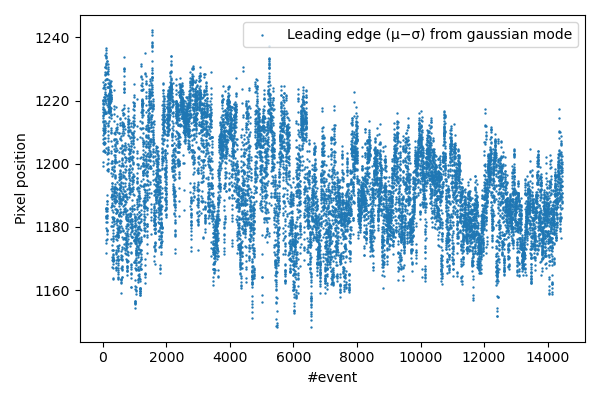

In [54]:


idx = np.arange(len(leading_edge))  # curve index, delay index, shot index, etc.

plt.figure(figsize=(6,4))
plt.scatter(idx, leading_edge, s=.5, label="Leading edge (μ−σ) from gaussian mode")
# plt.scatter(idx, leading_edge_fit, s=.1, label="Leading edge (μ−σ) from fit")
# plt.scatter(idx, leading_edge_max, s=.1, label="Leading edge (μ−σ) from max diff gaussian mode")
# plt.scatter(idx, leading_edge_fit_max, s=.1, label="Leading edge (μ−σ) from max diff fit")
# plt.plot(idx, leading_edge_fit-leading_edge, label="difference leading edge ")
# plt.scatter(idx, trailing_edge, s=5, label="Trailing edge (μ+σ)")
plt.xlabel("#event")
plt.ylabel("Pixel position")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
print('TT_test  :', ts[idx][0], ts[idx][-1])     # first < last  => ascending
# in Plot_Time:
# print('PlotTime :', dat['timestamp'][0], dat['timestamp'][-1])

TT_test  : 4861173239100610210 4861173436593409192


Text(0.5, 1.0, 'mu - sigma')

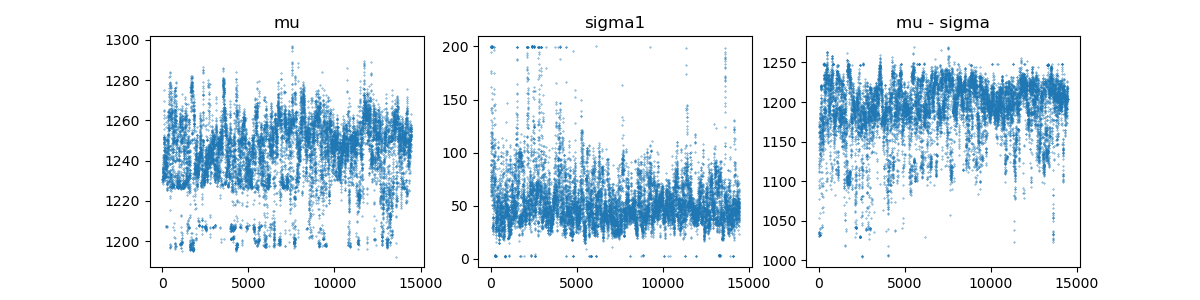

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(12,3), sharex=True)
ax[0].scatter(np.arange(len(mu_fit)),    mu_fit,           s=.1); ax[0].set_title('mu')
ax[1].scatter(np.arange(len(sigma_fit1)), sigma_fit1,      s=.1); ax[1].set_title('sigma1')
ax[2].scatter(np.arange(len(mu_fit)),    mu_fit-sigma_fit1, s=.1); ax[2].set_title('mu - sigma')

## Define ROI and save

From the scatter plot above determine the ROI and determine the low and high of the ROI, everything outside of that range will be set to the mean of the points inside the ROI

POSSIBLE IMPROVEMENT: instead of just using the mean, we coudl implement a nearest neighbour interpolation here


The results here will be saved to a txt file that will then be loaded when binning the data in 'process.py' to correct the nominal timing

In some cases with a very damaged target, the Gaussian moment seems to give a better estimate of the edge position than the fit, int that case set 'usefit' to False

In [ ]:

# np.savetxt(f"proc/leading_edge1{run}.txt", leading_edge)
low = 1180
high =1230
usefit = True # if true use fit, if false use Gaussian moment

if usefit:
    mean = np.nanmean(leading_edge_fit[np.logical_and(leading_edge_fit<high,leading_edge_fit>low)])
    leading_edge_fit[leading_edge_fit>high]=mean
    leading_edge_fit[leading_edge_fit<low]=mean
    # np.savetxt(f"proc/leading_edge_{run}.txt", leading_edge_fit)
else:
    mean = np.nanmean(leading_edge[np.logical_and(leading_edge<high,leading_edge>low)])
    leading_edge[leading_edge>high]=mean
    leading_edge[leading_edge<low]=mean
    # np.savetxt(f"proc/leading_edge_{run}.txt", leading_edge)



494/3699 replaced (13.4%), fill mean = 1120.53 px, NaNs left = 0


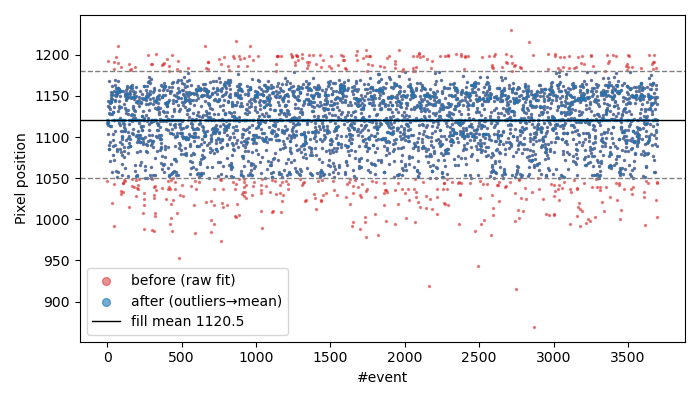

In [13]:
low, high = 1050, 1180

raw = leading_edge_fit.copy()                      # before
inwin = (raw > low) & (raw < high)
mean = np.nanmean(raw[inwin])

clipped = raw.copy()                               # after
clipped[raw > high] = mean
clipped[raw < low]  = mean

n_clip = np.sum(~inwin & ~np.isnan(raw))
print(f'{n_clip}/{len(raw)} replaced ({100*n_clip/len(raw):.1f}%), '
      f'fill mean = {mean:.2f} px, NaNs left = {np.isnan(clipped).sum()}')

idx = np.arange(len(raw))
plt.figure(figsize=(7,4))
plt.scatter(idx, raw,     s=2, c='tab:red',  alpha=0.5, label='before (raw fit)')
plt.scatter(idx, clipped, s=2, c='tab:blue', alpha=0.6, label='after (outliers→mean)')
plt.axhline(low,  ls='--', c='gray', lw=1)
plt.axhline(high, ls='--', c='gray', lw=1)
plt.axhline(mean, ls='-',  c='k',    lw=1, label=f'fill mean {mean:.1f}')
plt.xlabel('#event'); plt.ylabel('Pixel position')
plt.legend(markerscale=4); plt.tight_layout(); plt.show()

In [14]:
from scipy.spatial import cKDTree

def knn_aggregate(coords, values, mask_good, k=50, queries=None, agg=np.nanmean):
    """
    k-nearest-neighbour aggregation along an arbitrary coordinate.

    For each query sample, find the k nearest *good* samples (by distance in
    `coords`) and reduce their values with `agg`. General purpose: fill
    outliers/NaNs from local context, smooth a trace, interpolate onto good points.

    Parameters
    ----------
    coords : (N,) or (N, D) array
        Position of each sample for the distance metric. 1-D -> nearest in
        index/time/energy; N-D -> nearest in that space. np.arange(N) gives
        plain acquisition-order neighbours.
    values : (N,) array            values to aggregate
    mask_good : (N,) bool          samples allowed to act as neighbours (in-ROI, finite)
    k : int                        number of nearest good neighbours
    queries : (M,) int, optional   sample indices to estimate (default: all N)
    agg : callable                 reduction over neighbours, axis=1 (nanmean, nanmedian, ...)

    Returns
    -------
    est : (M,) array               aggregated neighbour value per query
    """
    coords = np.asarray(coords, float)
    if coords.ndim == 1:
        coords = coords[:, None]
    values = np.asarray(values, float)
    good = np.flatnonzero(mask_good)
    if good.size == 0:
        raise ValueError("no good samples to draw neighbours from")
    k = min(k, good.size)
    queries = np.arange(coords.shape[0]) if queries is None else np.asarray(queries)
    _, nn = cKDTree(coords[good]).query(coords[queries], k=k)
    if k == 1:
        nn = nn[:, None]
    return agg(values[good][nn], axis=1)

In [15]:
low, high = 1050, 1180
raw  = leading_edge_fit.copy()
good = (raw > low) & (raw < high) & np.isfinite(raw)     # in-ROI neighbours only
bad  = np.flatnonzero(~good)                              # outliers + NaNs

knn_filled = raw.copy()
knn_filled[bad] = knn_aggregate(np.arange(len(raw)), raw, good,
                                k=100, queries=bad, agg=np.nanmedian)

print(f'{bad.size}/{len(raw)} replaced ({100*bad.size/len(raw):.1f}%) via 50-NN local median')
# np.savetxt(f"proc/leading_edge_{run}.txt", knn_filled)

494/3699 replaced (13.4%) via 50-NN local median


In [16]:
low, high = 1170, 1225
mode   = 'drop'      # 'fill' = global mean | 'knn' = local median | 'drop' = ignore outliers
usefit = True       # True: use fit edge; False: use Gaussian-moment edge
k      = 100        # neighbours, knn mode only

raw  = (leading_edge_fit if usefit else leading_edge).copy()
good = (raw > low) & (raw < high) & np.isfinite(raw)
bad  = np.flatnonzero(~good)

edges = raw.copy()
if   mode == 'fill': edges[bad] = np.nanmean(raw[good])
elif mode == 'knn':  edges[bad] = knn_aggregate(np.arange(len(raw)), raw, good,
                                                 k=k, queries=bad, agg=np.nanmedian)
elif mode == 'drop': edges[bad] = np.nan
else: raise ValueError(f"unknown mode {mode!r}")

np.savetxt(f"proc/leading_edge_{run}.txt", edges)
note = {'fill': 'global mean', 'knn': f'{k}-NN local median', 'drop': 'NaN (dropped downstream)'}[mode]
print(f"[{mode}] {bad.size}/{len(raw)} outliers ({100*bad.size/len(raw):.1f}%) "
      f"outside [{low}, {high}] → {note}")

[drop] 619/3716 outliers (16.7%) outside [1170, 1225] → NaN (dropped downstream)


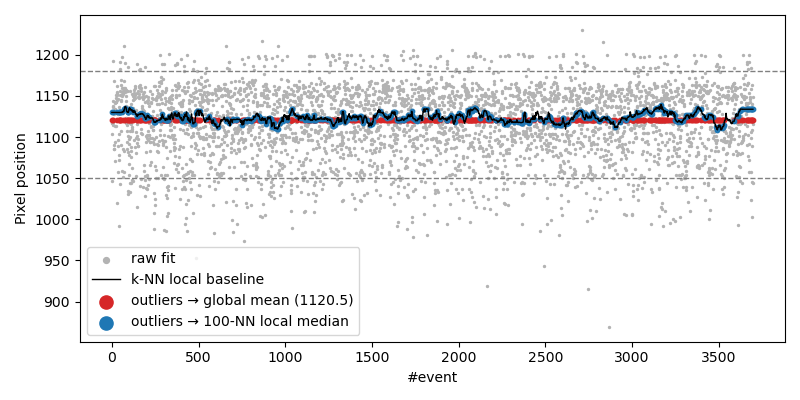

In [17]:
idx = np.arange(len(raw))

mean = np.nanmean(raw[good])                              # current behaviour
global_filled = raw.copy(); global_filled[~good] = mean

baseline = knn_aggregate(idx, raw, good, k=100, agg=np.nanmedian)  # local trend, all points

plt.figure(figsize=(8,4))
plt.scatter(idx, raw, s=2, c='0.7', label='raw fit')
plt.plot(idx, baseline, c='k', lw=1, label='k-NN local baseline')
plt.scatter(idx[~good], global_filled[~good], s=10, c='tab:red',
            label=f'outliers → global mean ({mean:.1f})')
plt.scatter(idx[~good], knn_filled[~good],   s=10, c='tab:blue',
            label='outliers → 100-NN local median')
plt.axhline(low, ls='--', c='gray', lw=1); plt.axhline(high, ls='--', c='gray', lw=1)
plt.xlabel('#event'); plt.ylabel('Pixel position')
plt.legend(markerscale=3); plt.tight_layout(); plt.show()

## Check if the edge position correlates with the nominal delay

Fortunately it doesn't seem to be the case, some weirdness at t=0

Text(0, 0.5, 'edge position')

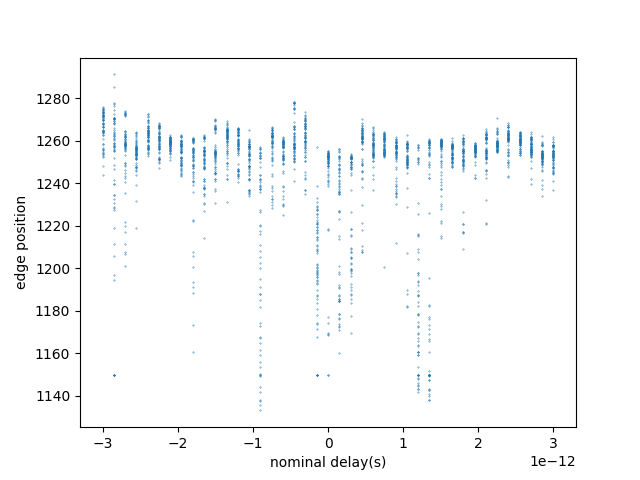

In [16]:
fig,ax=plt.subplots(1,1)
ax.scatter(data.integrating.axis_svls.delay[:][mask_on[:]],leading_edge_fit,s=0.1)
ax.set_xlabel('nominal delay(s)')
ax.set_ylabel('edge position')

Plot some of the traces together with fit (dashed line) and Gaussian moment (solid line)

Scatter x and dot mark the position of leading edge determined with Gaussian moment and fit, respectively

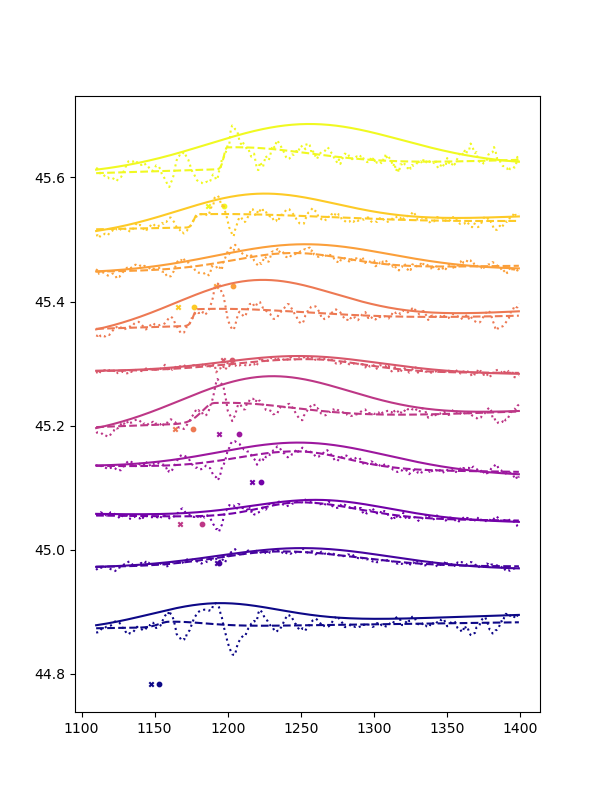

In [23]:
fig,ax =plt.subplots(1,1,figsize=(6,8))



cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(np.arange(580,590,1))))


f=2
c=0
for i in np.arange(580,590,1):
    ax.plot(px,asymmetric_gaussian(px,params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4])+params[0,0]*i*f,color=colors[c])
    ax.plot(px,asymmetric_gaussian(px,*params_fit[i,:])+params[0,0]*i*f,'--',color=colors[c])
    ax.plot(px,spectra[i]+params[0,0]*i*f,':',color=colors[c])
    ax.scatter(leading_edge[i],params[0,0]*i*f+params[i,-2],s=10,marker='x',color=colors[c])
    ax.scatter(leading_edge_fit[i],params[0,0]*i*f+params[i,-2],s=10,marker='o',color=colors[c])
    c=c+1

In [25]:
import h5py
key = 'intg/axis_svls/c_piranha_sum_full_area'      # 'piranha' is the chemrixs alias for this
with h5py.File(fname, 'r') as f:
    raw = f[key].shape[0]
filt = proc.data.integrating.axis_svls.piranha.shape[0]
print(f'raw {raw}, after countmask {filt}, dropped {raw-filt} ({100*(raw-filt)/raw:.1f}%)')

raw 28909, after countmask 15568, dropped 13341 (46.1%)


In [26]:
import numpy as np, scipy.stats as st
with h5py.File(fname, 'r') as f:
    cnt = f['intg/axis_svls/count'][()]
print('mode', st.mode(cnt, keepdims=False)[0], '| uniques', np.unique(cnt)[:15], '| n_unique', np.unique(cnt).size)

mode 335 | uniques [335 336] | n_unique 2
